In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import Galactic, ICRS, SkyCoord, GalacticLSR
from astropy import units as u
from modules.velocity_transformations import equatorial_UVW
from modules.vr_opt import VrOpt
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import normalized_mutual_info_score
import hdbscan
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph, sort_graph_by_row_values

from Distant_SigMA.SigMA.SigMA import SigMA
from scipy.stats import norm
from math import ceil
from astropy.table import Table
from pyia import GaiaData
from scipy.stats import gaussian_kde

In [2]:
# Plotting related stuff
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

In [3]:
#load data set 
tbl = Table.read('50pc_gaiaDR3.csv')
g=GaiaData(tbl)

In [4]:
def coord_transformation_single(ra, dec, distance, pmra_cosdec, pmdec, radial_velocity):
    c = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, distance=distance*u.pc,
                 pm_ra_cosdec=pmra_cosdec*u.mas/u.yr, pm_dec=pmdec*u.mas/u.yr,
                 radial_velocity=u.Quantity(radial_velocity,u.km/u.s))
    
    gal = c.galactic  # Galactic coordinates
    
    # Cartesian Galactic heliocentric positions and velocities
    pos_hel = gal.cartesian  # XYZ
    vel_hel = gal.velocity  # VUW in km/s computed from respective RVs
    
    # Cartesian Galactic LSR velocities
    gal_lsr = gal.transform_to(GalacticLSR())  # Adds constant  (11.1, 12.24, 7.25)
    vel_lsr = gal_lsr.velocity
    
    return c, gal, pos_hel, vel_hel, gal_lsr, vel_lsr 
c, gal, pos_hel, vel_hel, gal_lsr, vel_lsr =coord_transformation_single(g['ra'].value,g['dec'].value ,(1/g['parallax'].value)*1000,g['pmra'].value,g['pmdec'].value,g['radial_velocity'])

In [5]:
df = g.data.to_pandas()

In [166]:
df['x'] = pos_hel.x
df['y'] = pos_hel.y
df['z'] = pos_hel.z
df['x'] = df['x'].to_numpy().astype(float) # removes the unity
df['y'] = df['y'].to_numpy().astype(float)
df['z'] = df['z'].to_numpy().astype(float)

df['dist'] = (1/df.parallax)*1000
df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74
#df.to_csv("50pcGaia.csv", index=False)

Text(0, 0.5, 'y')

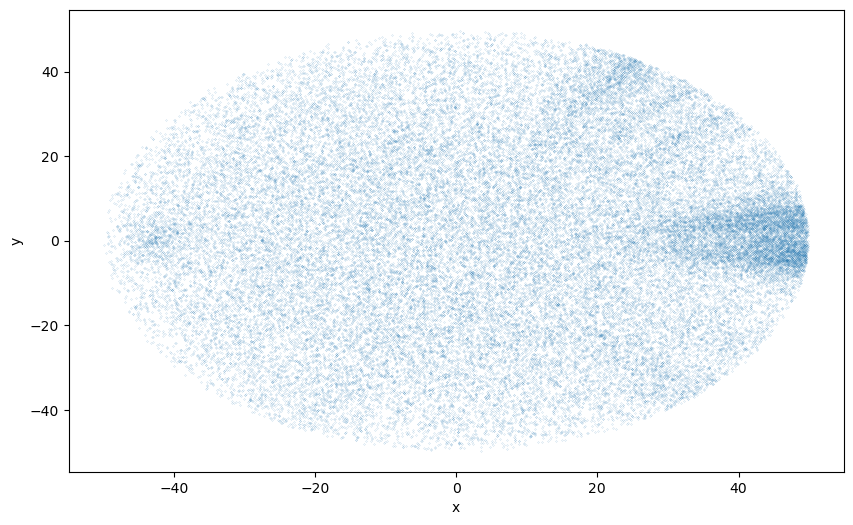

In [66]:
x_col, y_col = 'x', 'y'
#x_col, y_col = 'vx', 'vy'
#x_col, y_col = 'vt_ra', 'vt_dec'
#x_col, y_col = 'pmra', 'pmdec'
plt.figure(figsize=(10, 6))  
plt.scatter(df[x_col], df[y_col], s=0.01, alpha=0.9, zorder=2)
plt.xlabel(x_col)
plt.ylabel(y_col)

# Apply SigMA 

In [125]:
from TreeSigMA import TreeSigMAWithHierarchy  

knn_list=[15, 20, 25, 30]
cluster_features=['x', 'y', 'z']
sigma_kwargs = dict(
        nb_resampling=0,
        max_knn_density=int(np.max(knn_list)+1),
        beta=0.99,
        knn_initcluster_graph=35
    )

# Initialize TreeSigMA
tree_sigma = TreeSigMAWithHierarchy(
    data=df,
    cluster_features=cluster_features,
    **sigma_kwargs
)

# Run the SigMA clustering and build the hierarchy
print("Running TreeSigMA clustering...")
alpha_values = tree_sigma.run()
print("Clustering completed. Alpha values:", alpha_values)

# Build hierarchy 
print("\nBuilding hierarchy...")
tree_sigma.build_hierarchy()
print("Hierarchy built.")


node_id = list(tree_sigma.hierarchy.nodes.keys())[0]  # Pick the desired node ID
node = tree_sigma.hierarchy.nodes[node_id]


# Example: Analyzing the leaves
leaves = [node for node in tree_sigma.hierarchy.traverse_top_down() if node.is_leaf()]

Performing gradient ascend using a 20-NN density estimation.
Running TreeSigMA clustering...
Number of clusters did not increase by 1 at alpha=17 and alpha=0.00383806507754908.
Returning the hierarchy up to this point.
Clustering completed. Alpha values: [1.9597052869357867e-09, 2.939762792086853e-07, 8.392622691810736e-07, 2.2831138998258282e-06, 6.625564702766873e-06, 2.0704055652742692e-05, 0.00014664921110607576, 0.00033218262889855854, 0.00045369571150144505, 0.0005612573630436324, 0.0006733652005795343, 0.0007926708822982853, 0.0009564494727842265, 0.0011494169395883103, 0.0013283936898181303, 0.001891898171169304, 0.0027110496750508695, 0.00383806507754908, 0.0049840298814115, 0.005634627935993453, 0.00660799004214363, 0.0075319219149192485, 0.008107347317420521, 0.008833775283826562, 0.009404506169456595, 0.009674742055264862, 0.009789045545463282, 0.01024007169882274, 0.010813468314727848, 0.011557295941916013, 0.012308139681902475, 0.012542252724542013, 0.013288337907428394, 

In [126]:
for uid in tree_sigma.hierarchy.nodes:
            print(f"Node {uid}: {tree_sigma.hierarchy.nodes[uid].alpha_levels}")  

Node virtual_root: []
Node 5003_0: [0]
Node 13741_0: [0, 1, 2]
Node 28019_0: [0, 1, 2, 3, 4, 5]
Node 29295_0: [0, 1, 2, 3, 4]
Node 35182_0: [0, 1, 2, 3, 4, 5, 6, 7]
Node 49089_0: [0, 1]
Node 4063_1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 5003_1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Node 48968_2: [2, 3, 4, 5, 6]
Node 49089_2: [2, 3]
Node 8302_3: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Node 13741_3: [3, 4, 5, 6, 7, 8, 9, 10, 11]
Node 49089_4: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 51176_4: [4, 5, 6, 7, 8, 9]
Node 29224_5: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 29295_5: [5, 6, 7, 8, 9, 10]
Node 28019_6: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 46948_6: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 23102_7: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 48968_7: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 1208_8: [8]
Node 35182_8: [8, 9, 10, 11, 12, 13, 14, 15, 16]
Node 1208_9: [9, 10, 11, 12, 13, 14, 15, 16]
Node 11593_9: [9, 10, 11, 1

# Plot the Hierarchy

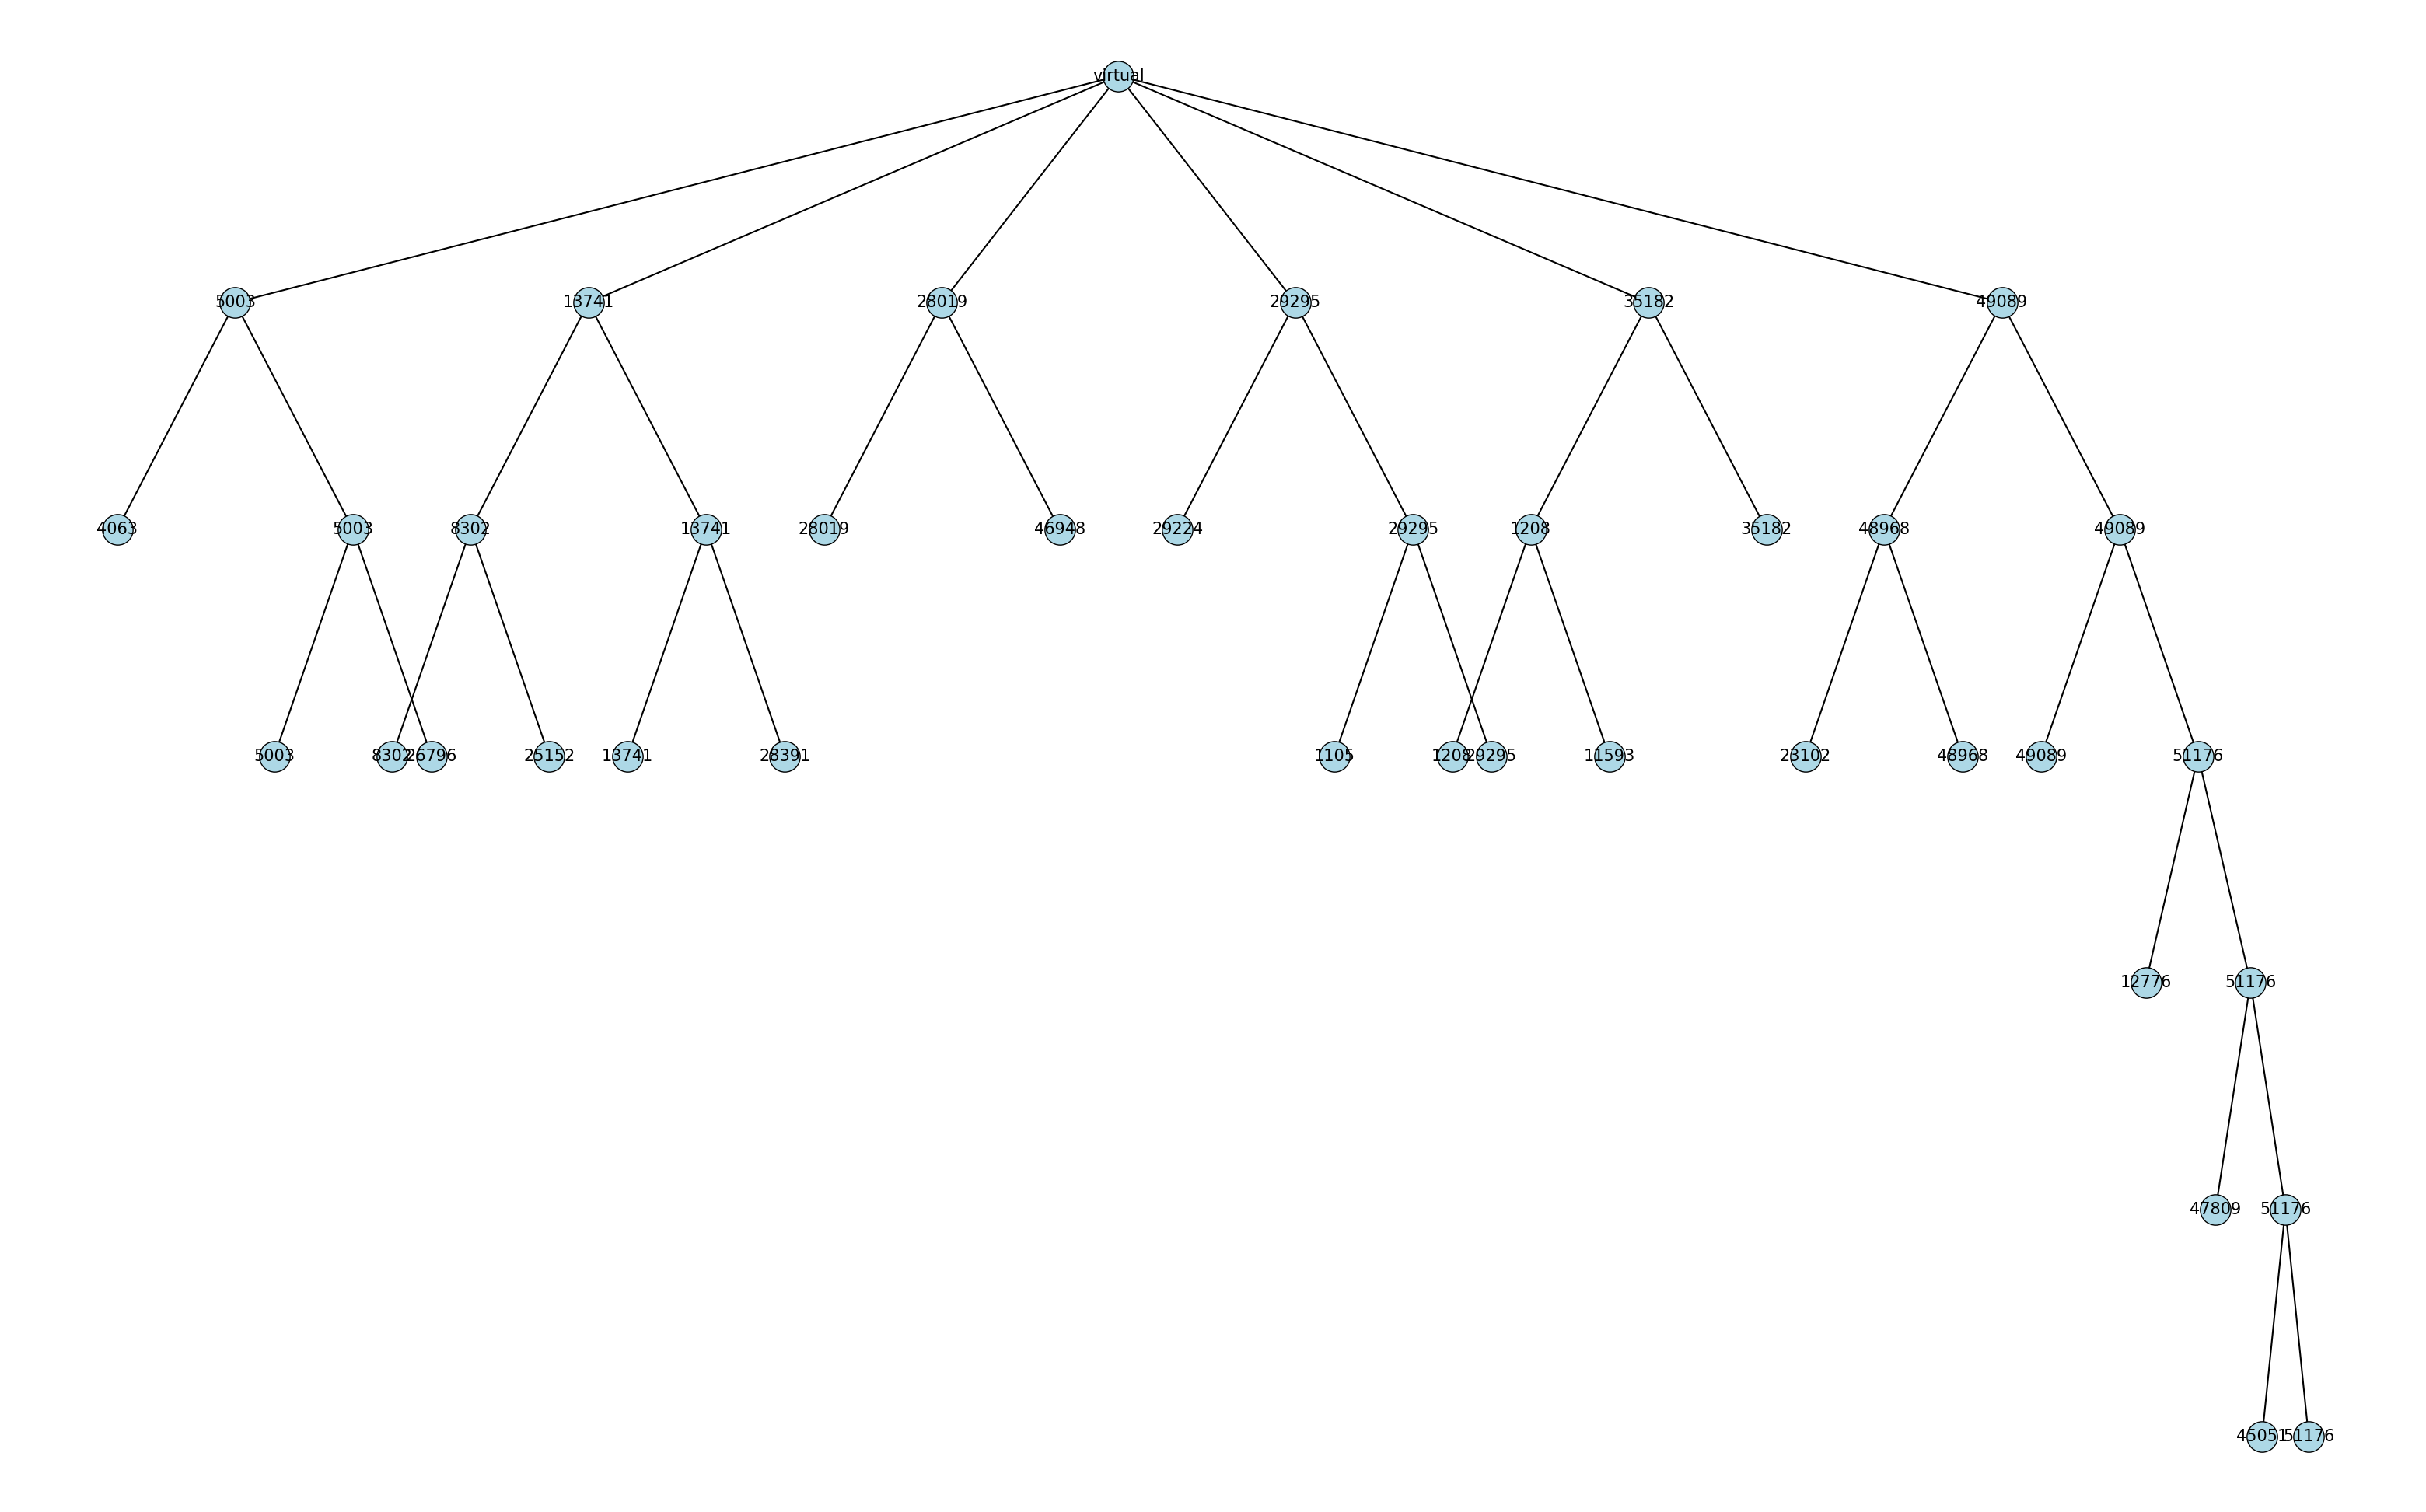

In [128]:
def plot_tree(node, x=0, y=0, level=0, x_spacing=1.5, y_spacing=1.5, node_positions=None, parent_positions=None, parent=None):
    """
    Recursively plot tree structure
    
    Args:
        node (TreeNode): The current node to plot.
        x (float): X-coordinate of the current node.
        y (float): Y-coordinate of the current node.
        level (int): Current level in the tree.
        x_spacing (float): Horizontal spacing between nodes.
        y_spacing (float): Vertical spacing between levels.
        node_positions (dict): Dictionary to store node positions for plotting.
        parent_positions (dict): Dictionary to store parent positions for edges.
        parent (tuple): Position of the parent node.
    """
    if node_positions is None:
        node_positions = {}
    if parent_positions is None:
        parent_positions = []

    # Store the current node's position
    node_positions[node.node_id] = (x, y)
    if parent is not None:
        parent_positions.append((parent, (x, y)))

    # Compute positions for children
    n_children = len(node.children)
    for i, child in enumerate(node.children):
        child_x = x - x_spacing * (n_children - 1) / 2 + i * x_spacing
        child_y = y - y_spacing
        plot_tree(child, x=child_x, y=child_y, level=level + 1,
                  x_spacing=x_spacing / 1.5, y_spacing=y_spacing,
                  node_positions=node_positions, parent_positions=parent_positions,
                  parent=(x, y))
    
    # Plot when at the root level
    if level == 0:
        fig, ax = plt.subplots(figsize=(40, 25))
        for (start, end) in parent_positions:
            ax.plot([start[0], end[0]], [start[1], end[1]], 'k-', zorder=1)
        for node_id, (nx, ny) in node_positions.items():
            current_node = tree_sigma.hierarchy.nodes[node_id]
            original_label = current_node.node_id.split('_')[0] # Get the original_label
            ax.scatter(nx, ny, s=800, c='lightblue', edgecolors='black', zorder=2)
            #ax.text(nx, ny, str(node_id), fontsize=10, ha='center', va='center', zorder=3)
            ax.text(nx, ny, f"{original_label}", fontsize=15, ha='center', va='center', zorder=3)
        ax.axis('off')
        plt.savefig('TreeSigMA.png')
        plt.show()

plot_tree(tree_sigma.hierarchy.root)

## Plot the data in each node

In [130]:
import os

# Create a directory to save the plots
output_dir = "TreeNode_XY_Plots"
os.makedirs(output_dir, exist_ok=True)

alphas = {0: 0.3, 1: 0.9, 2: 0.9, 3: 0.9}
zorders = {0: 0, 1: 1, 2: 1, 3: 1}

def plot_node_data(node, df, output_dir, x_col='x', y_col='y'):
    """
    Plot the data points contained in a tree node, colored by true labels.

    Args:
        node (TreeNode): Tree node to plot.
        df (pd.DataFrame): Dataframe containing the data points.
        output_dir (str): Directory to save the plots.
        x_col (str): Column name for x-axis data.
        y_col (str): Column name for y-axis data.
    """
    indices = node.data_indices
    if len(node.data_indices) == 0: #skip virtual node
        return
        
    node_data = df.iloc[indices]

    plt.figure(figsize=(8, 6))
    plt.scatter(node_data[x_col],
                node_data[y_col], 
                s=10
    )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Node ID: {node.node_id}")
   # plt.show()

    # Save plotx
    plt.savefig(os.path.join(output_dir, f"Node_{node.node_id}.png"))
    plt.close()

# Generate plots for each tree node
for node in tree_sigma.hierarchy.traverse_top_down():
    plot_node_data(node, df, output_dir)

# Prune the tree

In [132]:
#postprocessing the tree - if cluster got less than star_threshold stars, remove children from tree (if they are leaves)
df['x'] = df['x'].to_numpy().astype(float)
df['y'] = df['y'].to_numpy().astype(float)
df['z'] = df['z'].to_numpy().astype(float)

X = df[['x', 'y', 'z']].values
pruned_tree = tree_sigma.prune_tree(star_threshold=20, X=X)

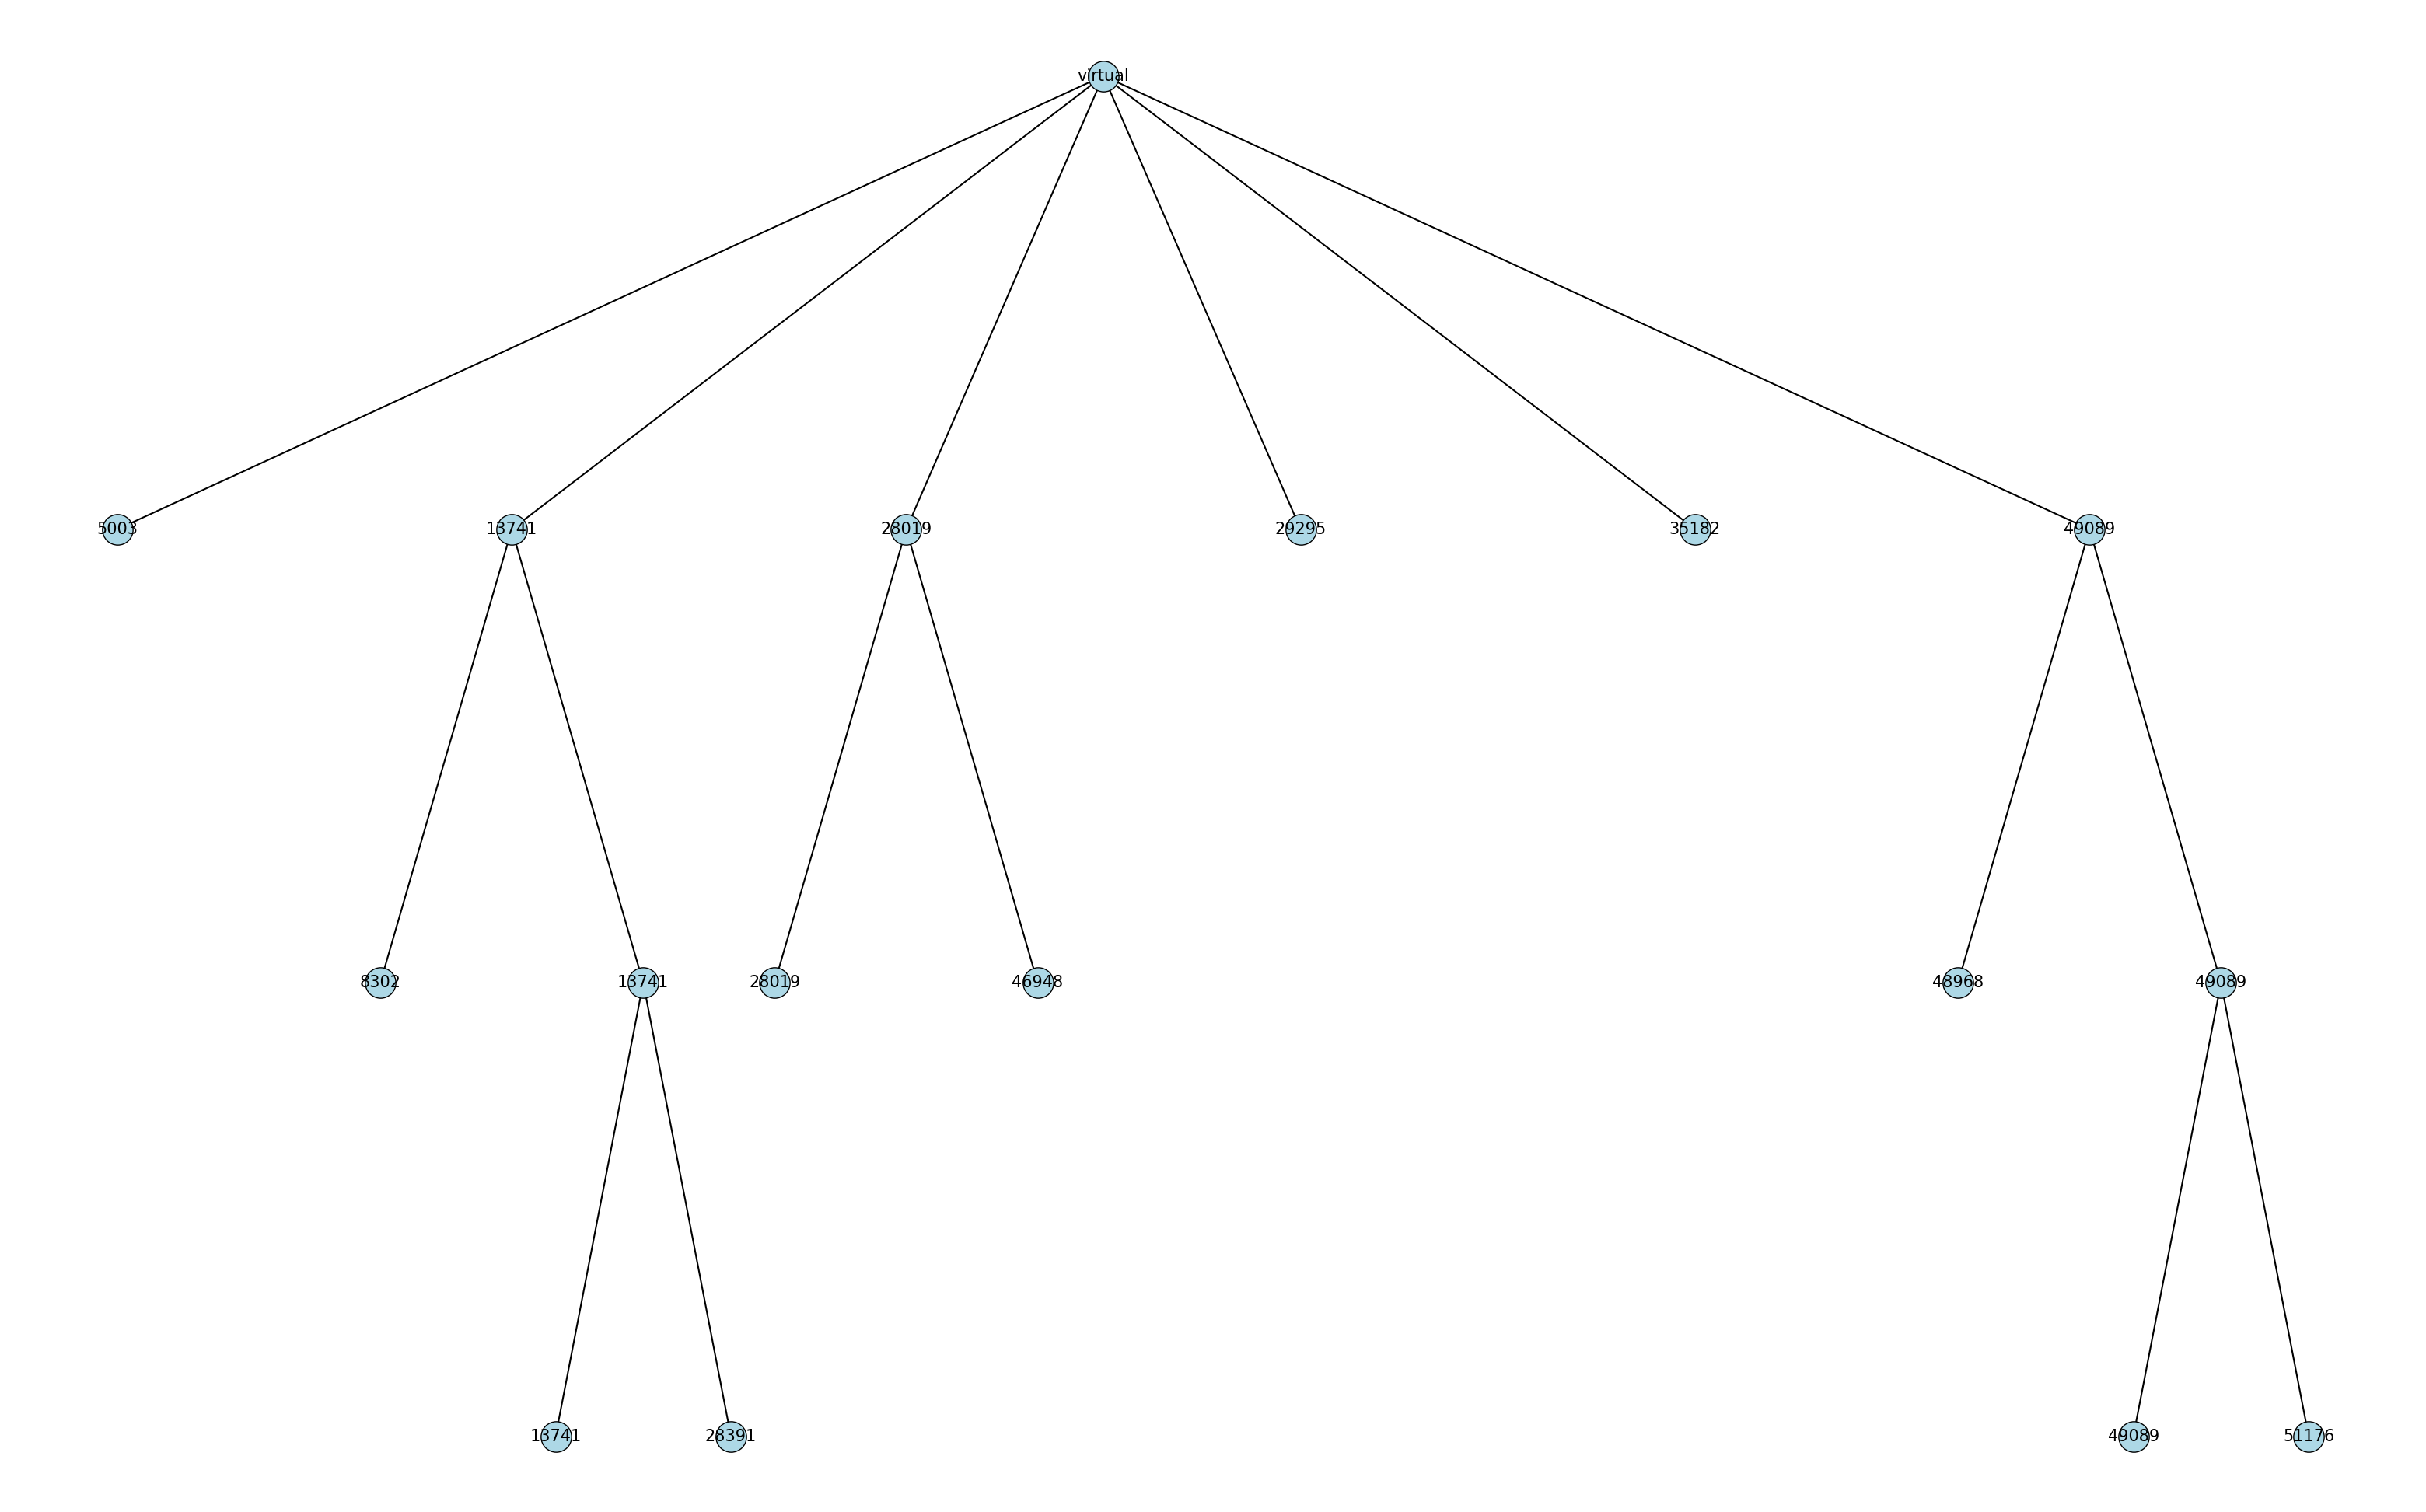

In [133]:
plot_tree(pruned_tree.hierarchy.root)

In [134]:
# Generate plots for each tree node
for node in pruned_tree.hierarchy.traverse_top_down():
    plot_node_data(node, df, output_dir)

# Plotly 3D plot of clusters

In [189]:
import plotly.express as px

# make a leaf node dataframe
def extract_leaf_nodes(tree, df):
    leaf_data = []
    for node in tree.hierarchy.traverse_top_down():
        if node.is_leaf():
            indices = node.data_indices
            if len(indices) > 0:
                node_data = df.iloc[indices].copy()
                node_data['cluster'] = node.node_id  # Cluster-ID
                leaf_data.append(node_data)
    return pd.concat(leaf_data, ignore_index=True) 

df_leaves = extract_leaf_nodes(pruned_tree, df)
df_leaves['size'] = 10 

# 3D-Scatter-Plot with Plotly
fig = px.scatter_3d(
    df_leaves, x='x', y='y', z='z', 
    color='cluster',  # colored Cluster
    size='size',
    title='3D Scatter Plot of Leaf Nodes',
    labels={'x': 'X', 'y': 'Y', 'z': 'Z'},
    opacity=0.8,
    size_max=10
)
fig.show()
fig.write_html("3d_scatter_plot.html")


In [138]:
df_leaves

,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,...,ebpminrp_gspphot_upper,libname_gspphot,x,y,z,dist,vt_ra,vt_dec,cluster,size
0,1636148068921376768,Gaia DR3 5912921509809469952,5912921509809469952,286300768,2016.0,264.635582,0.023203,-58.544378,0.019932,61.152174,...,NaN,NaN,14.213828,-7.034953,-3.985679,16.352648,1542.085388,-25846.536297,5003_0,4
1,1636148068921376768,Gaia DR3 4126014659966005248,4126014659966005248,1463570442,2016.0,255.330901,0.014219,-22.355543,0.009249,23.538225,...,0.0037,PHOENIX,41.563904,-0.078667,8.793935,42.484087,-25574.855753,-8651.706083,5003_0,4
2,1636148068921376768,Gaia DR3 4126217760359407488,4126217760359407488,1646321975,2016.0,253.348390,1.438513,-22.187301,0.715470,21.616812,...,NaN,NaN,44.970596,-0.859129,10.813046,46.260291,-2464.519569,436.230743,5003_0,4
3,1636148068921376768,Gaia DR3 4125890827455355264,4125890827455355264,64264631,2016.0,254.591393,2.466024,-22.783362,0.820265,22.242938,...,NaN,NaN,43.930752,-0.671162,9.532489,44.958089,-949.675303,521.309511,5003_0,4
4,1636148068921376768,Gaia DR3 4126080699371400064,4126080699371400064,648151132,2016.0,255.115790,0.180739,-22.127803,0.109328,30.366631,...,NaN,NaN,32.182115,-0.023067,6.982408,32.930884,-12781.820985,-73612.092971,5003_0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51965,1636148068921376768,Gaia DR3 6873346153611014016,6873346153611014016,1391646782,2016.0,304.468083,0.059208,-17.287198,0.029941,28.583766,...,NaN,NaN,28.047123,13.826132,-15.688842,34.984893,-5697.625512,-50568.088566,51176_4,4
51966,1636148068921376768,Gaia DR3 6873442051641322112,6873442051641322112,1052790547,2016.0,304.078654,0.039341,-16.735973,0.027023,29.360603,...,0.0118,MARCS,27.338586,13.721350,-14.978603,34.059246,14996.659293,8769.432499,51176_4,4
51967,1636148068921376768,Gaia DR3 6873649481380404096,6873649481380404096,226055911,2016.0,302.426957,0.052611,-17.703415,0.037250,25.895633,...,NaN,NaN,31.720819,14.788027,-16.319984,38.616550,42446.296228,-29273.613527,51176_4,4
51968,1636148068921376768,Gaia DR3 1793931771375192448,1793931771375192448,685452876,2016.0,323.648130,0.031699,22.037134,0.026412,20.899429,...,0.0037,MARCS,12.315786,42.755095,-17.600374,47.848197,22903.844266,13999.986230,51176_4,4


# Run Softmax in each node (Sebastians class)

In [169]:
import SemiMetricClustering.SemiMetricDensity as sm

In [171]:
node_indices = pruned_tree.hierarchy.get_all_indices() #list containing arrays of indices for each node
spec_node = 0

In [173]:
cluster_results = []
df.rename(columns={'x': 'X', 'y': 'Y', 'z': 'Z'}, inplace=True)

#for i, indices in enumerate(node_indices):
    
smc = sm.SemiMetricDensity(data=df, K=4, max_iter=1_000, method="random")

smc.compute_G(node_indices[spec_node])
p_labels, z = smc.run_softmax(
    initial_partition=None, theta=0.01, epsilon=0.005, rho_multiplier=np.ones(node_indices[spec_node].size, dtype=np.float32), verbose=True
)
labels_smc = smc.get_clusters(p_labels)
   
  #  labels_smc, z = smc.fit(
        # ATTENTION: Here you specify the indices of the data points you want to run softmax on
        # If you want to run on all data points, set indices=None. Otherwise, pass a numpy array containing the target indices
   #     indices=indices,
        # remaining parameters
    #    theta=0.01, epsilon=0.005, init_features=['x', 'y', 'z'], #epsilon must be smaller than theta 
    #    expected_signal_percentage=0.09, transition_speed=20,#ts 10-50 
        # not important parameters, do not change for now
    
    #    verbose=True, run_trial=True, A=A, dx=0.01
  #  )
cluster_results.append((labels_smc, node_indices[spec_node]))

Initializing probabilities randomly with 4 clusters...
Number of softmax iterations: 10


In [191]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Spalten umbenennen
df.rename(columns={'X': 'x', 'Y': 'y', 'Z': 'z'}, inplace=True)

def plt_result_node(node_index, df, labels, x_col='x', y_col='y', dx=2):
    """
    Plot softmax clusters for a specific node.

    node_index (int): Index of the current node.
    df (pd.DataFrame): Data containing x and y coordinates.
    labels (np.array): Cluster labels for the data points.
    x_col (str): Column name for x-axis data.
    y_col (str): Column name for y-axis data.
    dx (float): Padding for the plot axes.
    """
    unique_clusters = np.unique(labels[labels >= 0])  # Exclude -1 (unclustered points)
    n_clusters = len(unique_clusters)

    # Skip plotting if no clusters are detected
    if n_clusters == 0:
        print(f"Node {node_index + 1}: No clusters detected. Skipping.")
        return

    fig, ax = plt.subplots(1, n_clusters, figsize=(n_clusters * 5, 5), squeeze=False)
    ax = ax.flatten()

    for i, cluster in enumerate(unique_clusters):
        cluster_indices = labels == cluster
        cluster_data = df.loc[cluster_indices]

        ax[i].scatter(cluster_data[x_col], cluster_data[y_col], s=10, alpha=0.7)
        ax[i].set_title(f"Node {node_index}, Cluster {cluster}", fontsize=20)
        ax[i].set_xlim(df[x_col].min() - dx, df[x_col].max() + dx)
        ax[i].set_ylim(df[y_col].min() - dx, df[y_col].max() + dx)

    plt.tight_layout()
    plt.show()


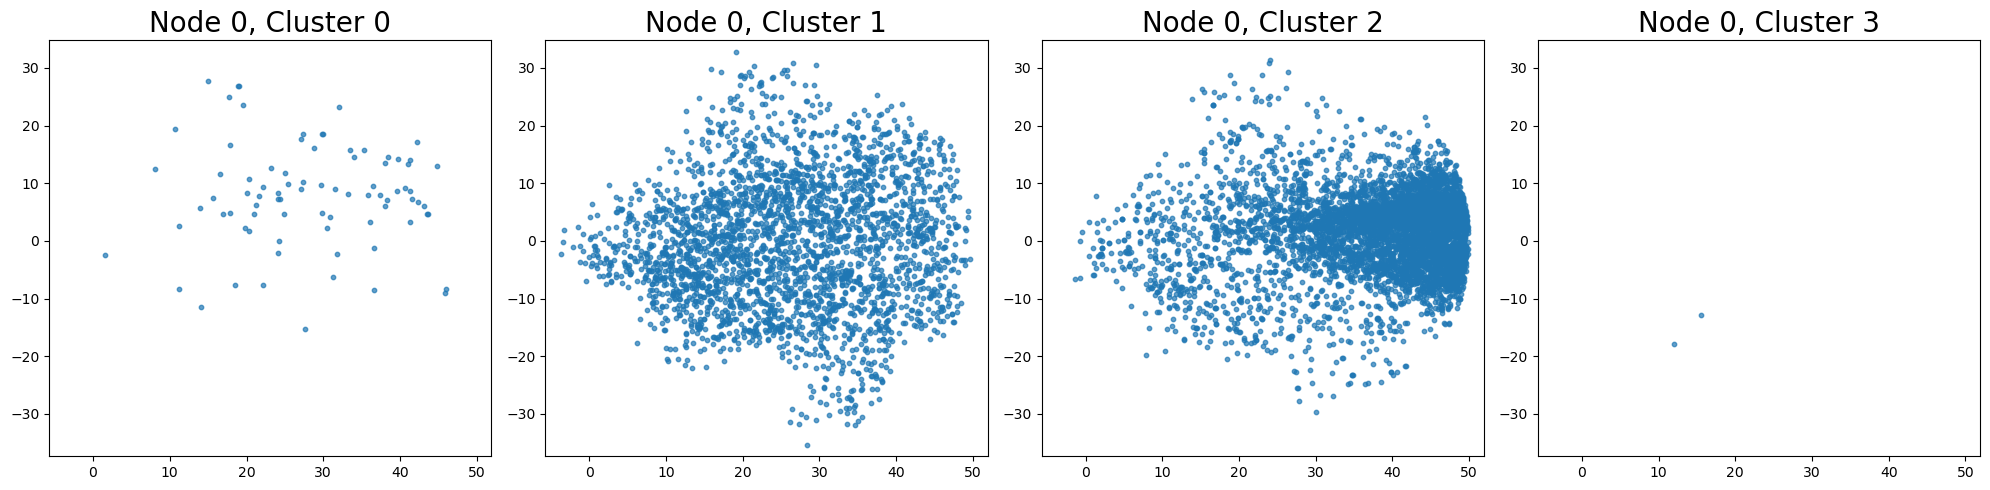

In [193]:

for node_index, (labels_smc, indices) in enumerate(cluster_results):
    # Create a temporary DataFrame for the current node's data
    node_df = df.iloc[indices].copy()  # Select only the points in this node

    plt_result_node(
        node_index = node_index,
        df=node_df,
        labels=labels_smc,
        x_col='x',
        y_col='y'
    )